In [1]:
"""Inserts"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Callable


### Test

In [2]:
"""Reading data"""
training_data=pd.read_parquet("data_parquet_2026/train.parquet")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop_duplicates
test_data = pd.read_parquet("data_parquet_2026/test.parquet")


In [3]:
""" Ségrégation des profiles"""
n=int(len(training_data["power"])/len(training_data["sensor"].unique())/3) #27384/3 = 9128
power1 = training_data.query("sensor =='N0000'")
power2 = training_data.query("sensor =='N0000'")
power3 = training_data.query("sensor =='N0000'")

for senso in training_data["sensor"].unique():
    power1 = pd.concat((power1, training_data[training_data["sensor"] == senso][:n]))
    power2 = pd.concat((power2, training_data[training_data["sensor"] == senso][n+1:2*n]))
    power3 = pd.concat((power3, training_data[training_data["sensor"] == senso][2*n+1:]))

#power1.plot.scatter(x="time", y="power", alpha=0.5)
#power2.plot.scatter(x="time", y="power", alpha=0.5)
#power3.plot.scatter(x="time", y="power", alpha=0.5)

<Axes: xlabel='time', ylabel='temperature'>

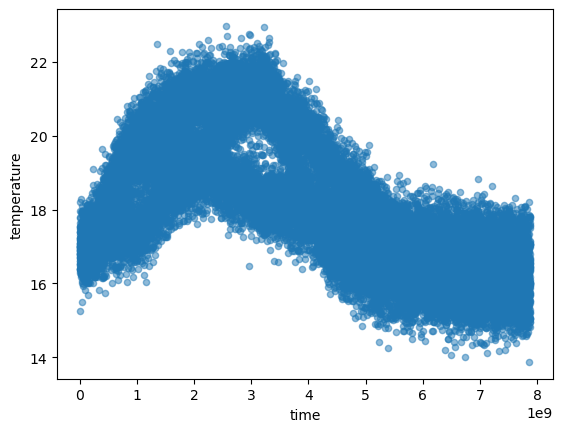

In [ ]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("sensor=='N418' and 0< temperature<35 and time < 1e10")
sampleP.plot.scatter(x="time", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

In [ ]:
"""graphes tous pour 1 senseur"""

sampleN418 = power3

#sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
#sampleN418.query("-100 < temperature < 200").plot.scatter(x="time", y="temperature", alpha=0.5)
#sensors.query("sensor == 'N418'")
sampleN418["time"]= sampleN418["time"]/864000
sampleN418.tail()


In [ ]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)



In [ ]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("time <= 1800000 and sensor=='N418'")
sampleP.head(10)

sampleP.plot.scatter(x="power", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

In [ ]:
a = sampleP["power"].diff(periods=864000)

a.head(20)
power1 = training_data.query("power == 500.0000 or power == 1000.0000 or power == 1500.0000")
power1.plot.scatter(x="time", y="power", alpha=0.5)


In [ ]:
"""graphes tous pour 1 senseur"""

sampleN418 = training_data.query(" sensor=='N418'")
sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418.plot.scatter(x="power", y="temperature", alpha=0.5)
sensors.query("sensor == 'N418'")

In [ ]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)
c=b["power"].pct_change(periods=1)


In [ ]:
sampleN418b = sampleN418.sample(1000)
sampleN418b.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418b.plot.scatter(x="time", y="temperature", alpha=0.5)


## I. First Model: KNN Method

### 1. Distance Metrics

In [ ]:
def man_dist(sample_coo: pd.DataFrame, train_set_coo: pd.DataFrame) -> pd.DataFrame:

    """Computes the Manhattan distance between a sample and all train sensors, and add
    their values in a new column of train_set_coo.
    Args:
        sample_coo: Dataset of the sample's coordinates
        train_set_coo: Dataset of the sensors' coordinates
    Returns:
        train_set_coo_with_dist: train_set_coo with a column "distance", filled.
    """

    coor_train = np.array([train_set_coo["coor_x"], train_set_coo["coor_y"]]).T
    coor_sample = np.array([sample_coo["coor_x"], sample_coo["coor_y"]])

    train_set_coo["distance"] = np.abs(coor_train - coor_sample).sum(axis = 1)

    return train_set_coo
   


def eucli_dist(sample_coo: pd.DataFrame, train_set_coo: pd.DataFrame) -> pd.DataFrame:

    """Computes the Euclidian distance between a sample and all train sensors, and add
    their values in a new column of train_set_coo.
    Args:
        sample_coo: Dataset of the sample's coordinates
        train_set_coo: Dataset of the sensors' coordinates
    Returns:
        train_set_coo_with_dist: train_set_coo with a column "distance", filled.
    """
    
    coor_train = np.array([train_set_coo["coor_x"], train_set_coo["coor_y"]]).T
    coor_sample = np.array([sample_coo["coor_x"], sample_coo["coor_y"]])

    train_set_coo["distance"] = np.sqrt(((coor_train - coor_sample) ** 2).sum(axis = 1))

    return train_set_coo


### 2. Distance Score

In [ ]:
def distance_score(neighbors:pd.DataFrame,
                   score_parameter: float = 1) -> pd.DataFrame:
    
    """Replace the "distance" column by a "score" one to each given neighbor sensor,
    depending on their distance to the sample.
    The closer is the sample, the higher the score. We set an upper limit to it
    to avoid giving "blind confidence" to "very close" sensors.
    Args:
        neighbors: neighbor sensors, with "distance" column, regarding the sample.
        score_parameter: Hyper-parameter, set to 1 by default.
    Returns:
        neighbors: Updated with the "score" column.
    """

    scores = 1 / (score_parameter * neighbors["distance"] + 1)

    # We replace the distance column (which we don't need anymore) by the "score" one.
    neighbors["score"] = scores
    neighbors.drop(labels = ["distance"], axis = 1, inplace = True)
    
    return neighbors

### 3. Missing Values / Outliers managers A COMPLETER (docu)

In [ ]:
def missing_val_manager(sens):
    
    sens = sens.reset_index(drop=True)
    temp = 0
    memo = []

    for i, val in enumerate(sens["temperature"]):
        
        if not val == val: # if nan
            memo.append(i)       
                     
        else: # c'est pas un nan
            if temp is not int: # si on a une valeur en mémoire
                if len(memo) != 0: # et qu'il y avait des nan avant
                    sens.loc[memo,"temperature"] = (temp+sens["temperature"][i]) / 2 # on remplace les nan par la moyenne de la mémoire et l'actuel
                    memo = [] # on oublie
                temp = sens["temperature"][i]
                
            else: # pas de valeur en mémoire
                if len(memo) != 0: # mais des nan avant
                    sens.loc[memo,"temperature"]=sens["temperature"][i] # on remplaces les nan par la valeur d'après
                    memo = [] # on oublie
        
    return sens








"""On synthétisera tout le preprocessing dans les fonctions ci-dessous.
/!\ Il manque gestion des sensors avec nombre de nan excédentaires (expl: outliers extremes)"""



def first_clean(sensors_set: pd.DataFrame, lb: int = -100, ub: int = 200) -> pd.DataFrame:
    
    """We set upper and lower bounds to eliminate very extreme values which we've
    set to -100 and 200 degrees.
    Args:
        sensors_set: dataset of all sensors to preprocess, with values of time,
         power and temperature.
        lb: Lower bound
        ub: Upper bound
    Returns:
        sensors_set: with deleted "extreme" outliers.
     """
        
    for _, row in sensors_set.iterrows():
        if row["temerature"] and (row["temerature"] < lb or ub < row["temerature"]):
            row["temerature"] = np.nan

    return sensors_set


def window_cleaning(rows: pd.DataFrame, margin: float = 10) -> pd.DataFrame:

    """Cleans a set of rows computing the median, and cutting the values under and above margin-distance
    of the median, and replacing by this last.
    Args:
        rows: the rows to clean.
        margin: size of the safe zone, where the values are kept around the median.
    Returns:
        rows: the same rows with replaced outliers, by the median of the initial set.
    """

    med = np.median(rows.dropna()["temperature"])

    for _,row in rows.iterrows():

        if (row["temperature"] < med - margin) or (row["temperature"] > med + margin):
            row["temperature"] = med


def preprocessing(sensors_set: pd.DataFrame, window: int = 50, margin: float = 10) -> pd.DataFrame:

    """The global function to preprocess the Data. It first calls first_clean to delete
    'extreme' outliers, than clean each sensor one by one by looking at 'windows' of time
    values on their data, computing the median on such intervals, and replacing too-far values
    of the median by itself.
    Args:
        sensors_set: dataset of all sensors to preprocess, with values of time,
         power and temperature.
        window: amount of rows to take to compute the median.
        margin: size of the safe zone, where the values are kept around the median.
    Returns:
        sensors_set: with cleaner data
    """

    # Deleting values of the dumb sensors
    sensors_set = first_clean(sensors_set = sensors_set)

    for sample in sensors_set["sensor"].unique(): # We pick every specific sensor of the dataset


        ... # Add a line to pick each peculiar power


        for t in range(0, sensors_set["sensor" == sample].shape[0] - window - 1, window):

            # /!\ Faudra check que ca modifie bien les rows en question
            rows = sensors_set['sensor' == sample and (t*864000 <= 'time' <= (t + window)*864000)]
            rows = window_cleaning(rows=rows, margin=margin)

        # Last rows cleaning: we may have missed some with our window-long steps
        t = sensors_set["sensor" == sample].shape[0] - window - 1
        rows = sensors_set['sensor' == sample and (t*864000 <= 'time' <= (t + window)*864000)]
        rows = window_cleaning(rows=rows, margin=margin)

    return sensors_set

### 4. K-Nearest Neighbors

In [ ]:
def find_nearest_neighbors(
    sample_coo: pd.DataFrame, 
    train_set_coo: pd.DataFrame, 
    distance_fn: Callable = eucli_dist, 
    k: int = 7) -> pd.DataFrame:
    
    """Finds the names and distances of the k-Nearest Neighbors of one sample.
    Args:
        sample_coo: Coordinates of the sample
        train_set_coo: Dataset of the the sensors' coordinates
        distance_fn: Distance function
        k: Number of nearest neighbors considered, set to 7 by default
    Returns:
        neighbors: dataframe of the k-nearest neighbors of the sample, with their distances
        stored in a new "distance" column.
    """

    train_set_with_dist = distance_fn(sample_coo, train_set_coo)
    
    neighbors = train_set_with_dist.sort_values(by=["distance"]).head(k)
    
    return neighbors

### 5. Prediction Functions

In [ ]:
def prediction_single(
    sample_coo: pd.DataFrame, 
    train_set_coo: pd.DataFrame,
    train_set_temp_at_t: pd.DataFrame,
    distance_fn: Callable = eucli_dist, 
    k: int = 7) -> float:

    """Gives the final prediction of a given sample's temperature, while calling KNN. Calculates the
    mean value of the temperatures of the neighbors, weighted by their distance scores.
    Args:
        sample_coo: Coordinates of the sample
        train_set_coo: Dataset of the sensors' coordinates
        train_set_temp_at_t: Dataset of the sensors' temperatures at the time of the sample
        distance_fn: Distance function
        k: Number of nearest neighbors taken, set to 7 by default
    Returns:
        pred: The value of the predicted temperature of the sample
    """

    global neighbors_dict
    sample_name = sample_coo["sensor"]

    # We check if the current sample was already analyzed in the past
    if sample_name not in neighbors_dict:

        neighbors = find_nearest_neighbors(sample_coo = sample_coo, dataset = train_set_coo, distance_fn = distance_fn, k = k)
        
        # The dictionnary is filled directly with the scores (not the distances)
        neighbors_dict[sample_name] = distance_score(neighbors = neighbors)["score"].to_numpy

    temperatures = train_set_temp_at_t[train_set_temp_at_t.sensor in neighbors_dict[sample_name]]["temperature"]
    pred = np.sum(neighbors_dict[sample_name] * temperatures) / np.sum(neighbors_dict[sample_name])

    return pred



def prediction(
    validation_set_coo: pd.DataFrame,
    validation_set_times:pd.DataFrame,
    train_set_coo: pd.DataFrame,
    train_set_values: pd.DataFrame,
    distance_fn: Callable = eucli_dist, 
    k: int = 7) -> pd.DataFrame:

    """Gives the final predictions of all validation-set temperatures, while calling prediction_single.
    Args:
        validation_set_coo: Dataframe with names and coordinates of some sensors whom we "hide" the
         temperature values.
        validation_set_times: Dataframe with names and times of the validation set at which we want the
         model to evaluate the temperature (times with "not nan" temperatures)
        train_set_coo: Dataset of the "train" sensors' coordinates.
        train_set_values: Dataset of the "train" sensors' values of time and temperatures.
        distance_fn: Distance function (among Manhattan or Euclidian)
        k: Number of nearest neighbors taken, set to 7 by default
    Returns:
        pred: times_to_evaluate with a column "prediction", filled with the outputs of prediction_single.
    """

    validation_set_times["prediction"] = np.empty(validation_set_times.shape[0]) # Add new column to validation set

    # Loop over all the rows of the validation set
    for _, row in validation_set_times.iterrows():
        validation_set_times["prediction"]["sensor" == row["sensor"] and "time" == row["time"]] = prediction_single(
            sample_coo = validation_set_coo["sensor" == row["sensor"]],
            train_set_coo = train_set_coo,
            train_set_temp_at_t = train_set_values[train_set_values["time"] == row["time"]],
            distance_fn = distance_fn,
            k = k)

    return validation_set_times



### 6. Loss Function

In [ ]:
def loss(ground_truths: pd.DataFrame, prediction_set: pd.DataFrame) -> float:
    """ Computes accuracy.
    
    Args:
        ground_truths: Dataframe of the name of the sensors with their time, and real temperatures.
        prediction_set: Our "Prediction" dataframe, of the same structure as ground_truths, but with
        a column "prediction" instead of "temperature".
    Returns:
        float: The loss
    """
    real_temp = ground_truths["temperature"].to_numpy
    predictions = prediction_set["prediction"].to_numpy

    return np.sum((real_temp - predictions)**2)

### Training Session

In [ ]:
# Reading data
training_data=pd.read_parquet("data_parquet_2026/train.parquet")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop(columns=["coor_z"])
test_data = pd.read_parquet("data_parquet_2026/test.parquet")

In [ ]:
"""Dropping the test sensors, as we will train the model only with the training data"""
test_sensors = test_data["sensor"].unique()
train_sensors_labels = training_data["sensor"].unique()
train_sensors_set = sensors.set_index(keys="sensor").loc[train_sensors_labels].reset_index()


"""Partition of the training_data into our "training" and "validation" model's sets"""
# Validation/ train coordinates' sets partition, over the train_sensors_set
validation_sensors_coo = train_sensors_set.sample(frac = 1/5)
train_sensors_coo = train_sensors_set.drop(labels=validation_sensors_coo.index)

# Validation/ train values' sets partition, ignoring unknown data of validation,
# and replacing them in training set
validation_samples_with_temp = training_data.set_index(keys="sensor").drop(labels = train_sensors_coo["sensor"], axis=0).dropna().reset_index()
train_samples_with_temp = preprocessing(training_data.set_index(keys="sensor").drop(labels = validation_sensors_coo["sensor"], axis=0))

# We "forget" the temperature values of the validation set
validation_samples = validation_samples_with_temp.drop(["temperature"])

# Initialisation of neighbors_dict, which will stock the rows of the sensors with their scores
# to each given sample already evaluated.
neighbors_dict = {}


"""Let's train our model!"""

for k in range(5,10):
    validation_samples_with_pred = prediction(
        validation_set_coo = validation_sensors_coo,
        validation_set_times = validation_samples,
        train_set_coo = train_sensors_coo,
        train_set_values = train_samples_with_temp,
        distance_fn = eucli_dist, 
        k = k)
    

    """Let's evaluate it!"""
    get_loss = loss(
        ground_truths = validation_samples_with_temp,
        prediction_set= validation_samples_with_pred)
    
    print(f"Value of k: {k} \n Loss: {get_loss} \n --------- \n")
    


## II. A few improvements

### 1. Outliers Manager

### 2. n-Folder Validation


### Application

## III. Second model: Linear Regression

### 1. Prediction Function

### 2. Penalized Loss Function

### 3. Gradient Descent

### Application

## Tests post-fonctions

In [ ]:
for i in training_data.head(5)["temperature"].to_numpy:
    print(i)

"""sampleN418.isna().sum()
a=managing_missing_val(sampleN418)
a.isna().sum()
"""


In [ ]:
"""Test of the functions"""
train_data_expl = pd.DataFrame(data=np.array([[1,1,2,2,3,3,4,4,5,0],
                                     [1,3,2,4,1,3,2,4,0,5]]).T,
                                       columns=["coor_x","coor_y"], dtype='float64')
train_data_expl["sensor"] = ["N1","N2","N3","N4","N5","N6","N7","N8","N9","N10"]


test_data_expl = pd.DataFrame(data=np.array([[1.5,4.,4.5],
                                     [1.5,0.5,3.]]).T,
                                       columns=["coor_x","coor_y"], dtype = 'float64')
test_data_expl["sensor"] = ["N11","N12","N13"]

for _, sample in test_data_expl.iterrows():
  print(sample)
  print(eucli_dist(sample, train_data_expl))

nan
